# NBA Draft Intelligence
### PCA, Regression & Prospect Scoring | 2001–2026

**Authors:** Luc-Alexandre Grenier  
**Data:** [wyattowalsh/basketball](https://www.kaggle.com/datasets/wyattowalsh/basketball) — 65,000+ games, 4,000+ players, Kaggle

---

This project investigates whether NBA combine physical measurements predict player career outcomes.

| Part | Method | Research Question |
|---|---|---|
| 1 | PCA / Factor Analysis | What latent physical dimensions do combine measurements capture? |
| 2 | OLS Linear Regression | Do those dimensions predict career length? |
| 3 | K-Means + Prospect Scoring | Can we identify archetypes and score future draft classes? |

## Part 1 — Data Preparation & PCA

Three datasets are merged: **draft_combine_stats** (measurements), **draft_history** (pick position), and **common_player_info** (career span, accolades).
Ten combine variables are retained after dropping shooting drills with zero coverage in the 2001–2019 era.
Variables are z-score standardized before PCA; the Kaiser criterion (eigenvalue > 1) guides component selection.

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path(r'C:\Users\Luc\.cache\kagglehub\datasets\wyattowalsh\basketball\versions\231\csv')

combine     = pd.read_csv(DATA_DIR / 'draft_combine_stats.csv')
history     = pd.read_csv(DATA_DIR / 'draft_history.csv')
player_info = pd.read_csv(DATA_DIR / 'common_player_info.csv')

print('combine shape:     ', combine.shape)
print('history shape:     ', history.shape)
print('player_info shape: ', player_info.shape)

print('\ncombine columns:\n',     list(combine.columns))
print('\nhistory columns:\n',     list(history.columns))
print('\nplayer_info columns:\n', list(player_info.columns))

combine shape:      (1202, 47)
history shape:      (7990, 14)
player_info shape:  (4171, 33)

combine columns:
 ['season', 'player_id', 'first_name', 'last_name', 'player_name', 'position', 'height_wo_shoes', 'height_wo_shoes_ft_in', 'height_w_shoes', 'height_w_shoes_ft_in', 'weight', 'wingspan', 'wingspan_ft_in', 'standing_reach', 'standing_reach_ft_in', 'body_fat_pct', 'hand_length', 'hand_width', 'standing_vertical_leap', 'max_vertical_leap', 'lane_agility_time', 'modified_lane_agility_time', 'three_quarter_sprint', 'bench_press', 'spot_fifteen_corner_left', 'spot_fifteen_break_left', 'spot_fifteen_top_key', 'spot_fifteen_break_right', 'spot_fifteen_corner_right', 'spot_college_corner_left', 'spot_college_break_left', 'spot_college_top_key', 'spot_college_break_right', 'spot_college_corner_right', 'spot_nba_corner_left', 'spot_nba_break_left', 'spot_nba_top_key', 'spot_nba_break_right', 'spot_nba_corner_right', 'off_drib_fifteen_break_left', 'off_drib_fifteen_top_key', 'off_drib_fif

In [4]:
# Keep only the columns we actually need from history and player_info
# — specifically excluding anything already in combine

history_cols     = ['person_id', 'overall_pick', 'round_number', 'organization_type']
player_info_cols = ['person_id', 'from_year', 'to_year', 'greatest_75_flag']

# Clean the join keys
combine['player_id']     = combine['player_id'].astype(str).str.strip()
history['person_id']     = history['person_id'].astype(str).str.strip()
player_info['person_id'] = player_info['person_id'].astype(str).str.strip()

# Only keep real draft entries, one row per player
history_clean = (
    history[history['draft_type'] == 'Draft']
    .sort_values('overall_pick')
    .drop_duplicates(subset='person_id', keep='first')
)

# Join 1: combine + history
df = combine.merge(
    history_clean[history_cols],
    left_on='player_id', right_on='person_id',
    how='inner'
)

# Join 2: + player_info
df = df.merge(
    player_info[player_info_cols],
    on='person_id',
    how='inner'
)

# Check for any _x / _y columns — there should be NONE
suffix_cols = [c for c in df.columns if c.endswith('_x') or c.endswith('_y')]
print('Suffix columns (should be empty):', suffix_cols)
print('Shape:', df.shape)
print('Columns:', list(df.columns))

Suffix columns (should be empty): []
Shape: (546, 54)
Columns: ['season', 'player_id', 'first_name', 'last_name', 'player_name', 'position', 'height_wo_shoes', 'height_wo_shoes_ft_in', 'height_w_shoes', 'height_w_shoes_ft_in', 'weight', 'wingspan', 'wingspan_ft_in', 'standing_reach', 'standing_reach_ft_in', 'body_fat_pct', 'hand_length', 'hand_width', 'standing_vertical_leap', 'max_vertical_leap', 'lane_agility_time', 'modified_lane_agility_time', 'three_quarter_sprint', 'bench_press', 'spot_fifteen_corner_left', 'spot_fifteen_break_left', 'spot_fifteen_top_key', 'spot_fifteen_break_right', 'spot_fifteen_corner_right', 'spot_college_corner_left', 'spot_college_break_left', 'spot_college_top_key', 'spot_college_break_right', 'spot_college_corner_right', 'spot_nba_corner_left', 'spot_nba_break_left', 'spot_nba_top_key', 'spot_nba_break_right', 'spot_nba_corner_right', 'off_drib_fifteen_break_left', 'off_drib_fifteen_top_key', 'off_drib_fifteen_break_right', 'off_drib_college_break_left',

In [5]:
# Filter to draft classes 2001-2019
df['season'] = pd.to_numeric(df['season'], errors='coerce')
df = df[(df['season'] >= 2001) & (df['season'] <= 2019)].copy()
print('Rows after year filter:', len(df))

# Force from_year and to_year to numeric, compute career length
df['from_year'] = pd.to_numeric(df['from_year'], errors='coerce')
df['to_year']   = pd.to_numeric(df['to_year'],   errors='coerce')
df['career_length'] = (df['to_year'] - df['from_year']).clip(lower=0)

print('career_length — mean:', round(df['career_length'].mean(), 1),
      '  nulls:', df['career_length'].isna().sum())
print('\nFirst 5 rows of key columns:')
print(df[['player_name', 'season', 'overall_pick', 'career_length', 'greatest_75_flag']].head())

Rows after year filter: 485
career_length — mean: 6.1   nulls: 0

First 5 rows of key columns:
             player_name  season  overall_pick  career_length greatest_75_flag
0         Gilbert Arenas    2001            30           10.0                N
1      Brandon Armstrong    2001            23            2.0                N
2          Shane Battier    2001             6           12.0                N
3  Ruben Boumtje-Boumtje    2001            49            2.0                N
4        Michael Bradley    2001            17            4.0                N


In [6]:
# Define the combine variable groups
SIZE_VARS     = ['height_wo_shoes', 'weight', 'wingspan', 'standing_reach', 'body_fat_pct']
ATH_VARS      = ['standing_vertical_leap', 'max_vertical_leap',
                 'lane_agility_time', 'three_quarter_sprint', 'bench_press']
SHOOT15_VARS  = ['spot_fifteen_corner_left', 'spot_fifteen_break_left',
                 'spot_fifteen_top_key', 'spot_fifteen_break_right',
                 'spot_fifteen_corner_right']
SHOOTCOL_VARS = ['spot_college_corner_left', 'spot_college_break_left',
                 'spot_college_top_key', 'spot_college_break_right',
                 'spot_college_corner_right']

ALL_VARS = SIZE_VARS + ATH_VARS + SHOOT15_VARS + SHOOTCOL_VARS

# Check how many players actually have data for each variable
print(f'{"Variable":<35} {"Non-null":>8} {"Coverage":>10}')
print('-' * 56)
for col in ALL_VARS:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    n       = df[col].notna().sum()
    pct     = n / len(df) * 100
    flag    = '  ← sparse' if pct < 50 else ''
    print(f'{col:<35} {n:>8} {pct:>9.1f}%{flag}')

Variable                            Non-null   Coverage
--------------------------------------------------------
height_wo_shoes                          477      98.4%
weight                                   476      98.1%
wingspan                                 478      98.6%
standing_reach                           477      98.4%
body_fat_pct                             439      90.5%
standing_vertical_leap                   422      87.0%
max_vertical_leap                        421      86.8%
lane_agility_time                        415      85.6%
three_quarter_sprint                     420      86.6%
bench_press                              412      84.9%
spot_fifteen_corner_left                   0       0.0%  ← sparse
spot_fifteen_break_left                    0       0.0%  ← sparse
spot_fifteen_top_key                       0       0.0%  ← sparse
spot_fifteen_break_right                   0       0.0%  ← sparse
spot_fifteen_corner_right                  0       0.0%  ← spar

In [7]:
# Drop the shooting columns entirely — they have no data
USED_VARS = SIZE_VARS + ATH_VARS
print(f'Variables going into PCA: {len(USED_VARS)}')
print(USED_VARS)

# How many players have at least 5 of these 10 filled in?
non_null_counts = df[USED_VARS].notna().sum(axis=1)
print(f'\nPlayers with all 10 variables:  {(non_null_counts == 10).sum()}')
print(f'Players with 5-9 variables:     {((non_null_counts >= 5) & (non_null_counts < 10)).sum()}')
print(f'Players with fewer than 5:      {(non_null_counts < 5).sum()}')

Variables going into PCA: 10
['height_wo_shoes', 'weight', 'wingspan', 'standing_reach', 'body_fat_pct', 'standing_vertical_leap', 'max_vertical_leap', 'lane_agility_time', 'three_quarter_sprint', 'bench_press']

Players with all 10 variables:  363
Players with 5-9 variables:     109
Players with fewer than 5:      13


In [8]:
# Keep players with at least 5 of 10 variables, drop the rest
pca_df = df[USED_VARS + ['player_name', 'career_length', 'overall_pick',
                          'organization_type', 'position', 'greatest_75_flag']].copy()

pca_df = pca_df[non_null_counts >= 5].copy()
print(f'Players kept: {len(pca_df)}')

# Impute missing values with each column's median
from sklearn.impute import SimpleImputer

imputer      = SimpleImputer(strategy='median')
X_imputed    = imputer.fit_transform(pca_df[USED_VARS])
X_imputed_df = pd.DataFrame(X_imputed, columns=USED_VARS, index=pca_df.index)

print(f'Imputed matrix shape: {X_imputed_df.shape}')
print(f'Any NaNs remaining:   {X_imputed_df.isna().any().any()}')
print('\nVariable ranges:')
print(X_imputed_df.agg(['min','max','mean']).round(2).to_string())

Players kept: 472
Imputed matrix shape: (472, 10)
Any NaNs remaining:   False

Variable ranges:
      height_wo_shoes  weight  wingspan  standing_reach  body_fat_pct  standing_vertical_leap  max_vertical_leap  lane_agility_time  three_quarter_sprint  bench_press
min             67.75   161.0     70.00           89.50          2.70                   22.00              25.00               9.65                  2.96         0.00
max             85.75   302.6     92.50          115.50         20.80                   39.50              44.50              13.20                  3.81        26.00
mean            77.67   215.2     82.58          103.66          6.96                   29.57              35.08              11.31                  3.27        10.15


In [9]:
from sklearn.preprocessing import StandardScaler

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed_df)
X_scaled_df = pd.DataFrame(X_scaled, columns=USED_VARS, index=pca_df.index)

print('After scaling — mean and std per variable (mean ≈ 0, std ≈ 1):')
print(X_scaled_df.agg(['mean','std']).round(3).to_string())

After scaling — mean and std per variable (mean ≈ 0, std ≈ 1):
      height_wo_shoes  weight  wingspan  standing_reach  body_fat_pct  standing_vertical_leap  max_vertical_leap  lane_agility_time  three_quarter_sprint  bench_press
mean           -0.000  -0.000     0.000           0.000        -0.000                  -0.000             -0.000             -0.000                 0.000       -0.000
std             1.001   1.001     1.001           1.001         1.001                   1.001              1.001              1.001                 1.001        1.001


In [10]:
from sklearn.decomposition import PCA

pca_full    = PCA(n_components=10, random_state=42)
pca_full.fit(X_scaled)

eigenvalues = pca_full.explained_variance_
var_ratio   = pca_full.explained_variance_ratio_
cum_var     = np.cumsum(var_ratio)

print(f'{"PC":<6} {"Eigenvalue":>12} {"Variance %":>12} {"Cumulative %":>14}')
print('-' * 46)
for i in range(10):
    print(f'PC{i+1:<4} {eigenvalues[i]:>12.3f} {var_ratio[i]*100:>11.2f}% {cum_var[i]*100:>13.2f}%')

PC       Eigenvalue   Variance %   Cumulative %
----------------------------------------------
PC1           4.862       48.52%         48.52%
PC2           1.651       16.48%         64.99%
PC3           1.061       10.58%         75.58%
PC4           0.744        7.42%         83.00%
PC5           0.712        7.11%         90.11%
PC6           0.457        4.56%         94.67%
PC7           0.178        1.78%         96.45%
PC8           0.167        1.66%         98.11%
PC9           0.150        1.49%         99.61%
PC10          0.040        0.39%        100.00%


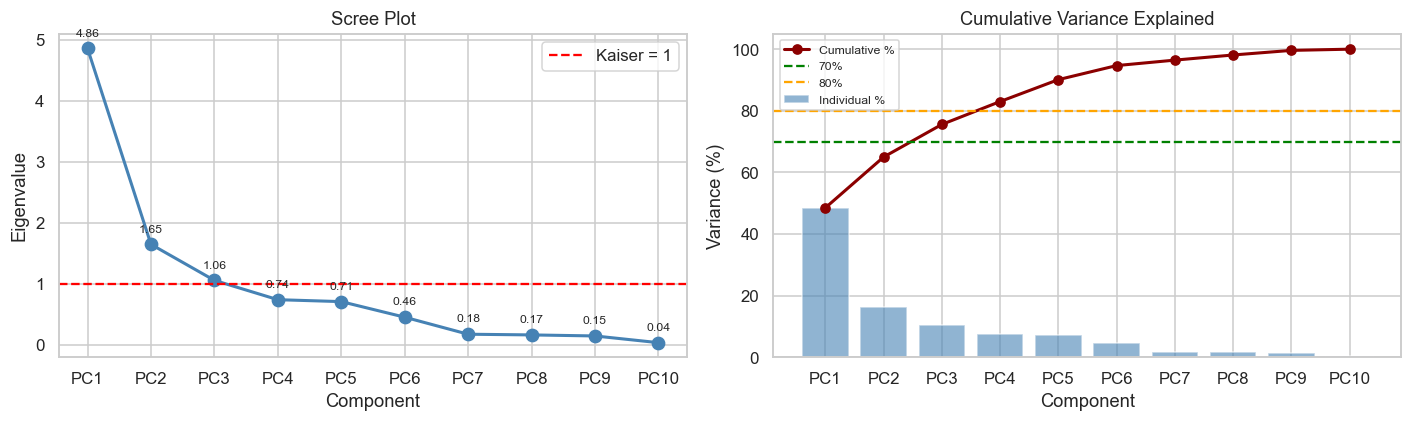

Saved: scree_plot.png


In [11]:
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pc_labels = [f'PC{i+1}' for i in range(10)]

# Scree plot
axes[0].plot(pc_labels, eigenvalues, 'o-', color='steelblue', lw=2, markersize=8)
axes[0].axhline(1, color='red', linestyle='--', lw=1.5, label='Kaiser = 1')
axes[0].set_title('Scree Plot')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Eigenvalue')
axes[0].legend()
for i, ev in enumerate(eigenvalues):
    axes[0].annotate(f'{ev:.2f}', (pc_labels[i], ev),
                     textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=8)

# Cumulative variance
axes[1].bar(pc_labels, var_ratio * 100, color='steelblue', alpha=0.6, label='Individual %')
axes[1].plot(pc_labels, cum_var * 100, 'o-', color='darkred', lw=2, markersize=6, label='Cumulative %')
axes[1].axhline(70, color='green',  linestyle='--', lw=1.5, label='70%')
axes[1].axhline(80, color='orange', linestyle='--', lw=1.5, label='80%')
axes[1].set_title('Cumulative Variance Explained')
axes[1].set_xlabel('Component')
axes[1].set_ylabel('Variance (%)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: scree_plot.png')

In [12]:
pca = PCA(n_components=3, random_state=42)
pca.fit(X_scaled)

loadings = pd.DataFrame(
    pca.components_.T,
    index=USED_VARS,
    columns=['PC1', 'PC2', 'PC3']
)

print(f'Variance retained: {pca.explained_variance_ratio_.sum():.1%}')
print()
print(f'{"Variable":<26} {"PC1":>8} {"PC2":>8} {"PC3":>8}')
print('-' * 52)
for var in USED_VARS:
    row = loadings.loc[var]
    print(f'{var:<26} {row.PC1:>8.3f} {row.PC2:>8.3f} {row.PC3:>8.3f}')

Variance retained: 75.6%

Variable                        PC1      PC2      PC3
----------------------------------------------------
height_wo_shoes               0.399    0.191   -0.202
weight                        0.373    0.305    0.207
wingspan                      0.376    0.255   -0.292
standing_reach                0.409    0.149   -0.222
body_fat_pct                  0.224   -0.017    0.606
standing_vertical_leap       -0.243    0.552   -0.193
max_vertical_leap            -0.318    0.431   -0.167
lane_agility_time             0.289   -0.037   -0.193
three_quarter_sprint          0.310   -0.274   -0.015
bench_press                   0.051    0.465    0.559


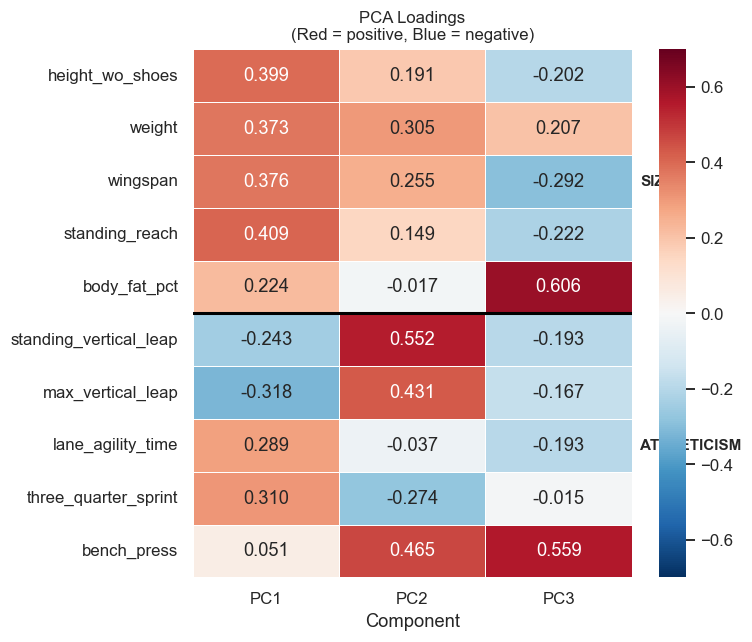

Saved: loadings_heatmap.png


In [13]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(loadings, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-0.7, vmax=0.7,
            linewidths=0.5, ax=ax)

ax.axhline(5, color='black', lw=2)   # divide size from athleticism

ax.set_title('PCA Loadings\n(Red = positive, Blue = negative)', fontsize=11)
ax.set_xlabel('Component')
ax.set_ylabel('')

# Label the groups
ax.annotate('SIZE', xy=(1.02, 0.75), xycoords='axes fraction',
            fontsize=10, fontweight='bold', va='center')
ax.annotate('ATHLETICISM', xy=(1.02, 0.25), xycoords='axes fraction',
            fontsize=10, fontweight='bold', va='center')

plt.tight_layout()
plt.savefig('outputs/loadings_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: loadings_heatmap.png')

In [14]:
scores = pca.transform(X_scaled)

scores_df = pd.DataFrame(scores, columns=['Size', 'Explosiveness', 'Strength'],
                          index=pca_df.index)

# Attach player info
scores_df['player_name']   = pca_df['player_name'].values
scores_df['career_length'] = pca_df['career_length'].values
scores_df['overall_pick']  = pca_df['overall_pick'].values
scores_df['position']      = pca_df['position'].values
scores_df['greatest_75']   = pca_df['greatest_75_flag'].values

print(f'Scores shape: {scores_df[["Size","Explosiveness","Strength"]].shape}')
print()
print('Top 5 players by Size score:')
print(scores_df.nlargest(5, 'Size')[['player_name','Size','Explosiveness','Strength','career_length']].round(2).to_string(index=False))
print()
print('Top 5 players by Explosiveness score:')
print(scores_df.nlargest(5, 'Explosiveness')[['player_name','Size','Explosiveness','Strength','career_length']].round(2).to_string(index=False))

def simplify_pos(pos):
    if pd.isna(pos): return "Unknown"
    pos = str(pos).upper()
    primary = pos.split("-")[0]
    if   primary == "C":  return "Center"
    elif primary == "PF": return "Forward"
    elif primary == "SF": return "Forward"
    elif primary == "SG": return "Guard"
    elif primary == "PG": return "Guard"
    else: return "Unknown"

scores_df["pos_simple"] = scores_df["position"].apply(simplify_pos)

Scores shape: (472, 3)

Top 5 players by Size score:
     player_name  Size  Explosiveness  Strength  career_length
 Brendan Haywood  5.96           0.37      1.18           13.0
DeMarcus Cousins  5.92          -1.01      2.56           11.0
      Eddy Curry  5.85           1.04      2.49           11.0
   Solomon Alabi  5.78          -2.32     -1.38            1.0
     Peter Ramos  5.76          -2.03     -1.60            0.0

Top 5 players by Explosiveness score:
    player_name  Size  Explosiveness  Strength  career_length
  Joe Alexander -0.69           3.20      0.65            1.0
Justin Anderson -1.83           3.19     -1.02            6.0
Harrison Barnes -1.13           3.17      0.62           11.0
     Alton Ford  0.60           3.15      1.27            2.0
   Semi Ojeleye -1.61           3.10      0.61            4.0


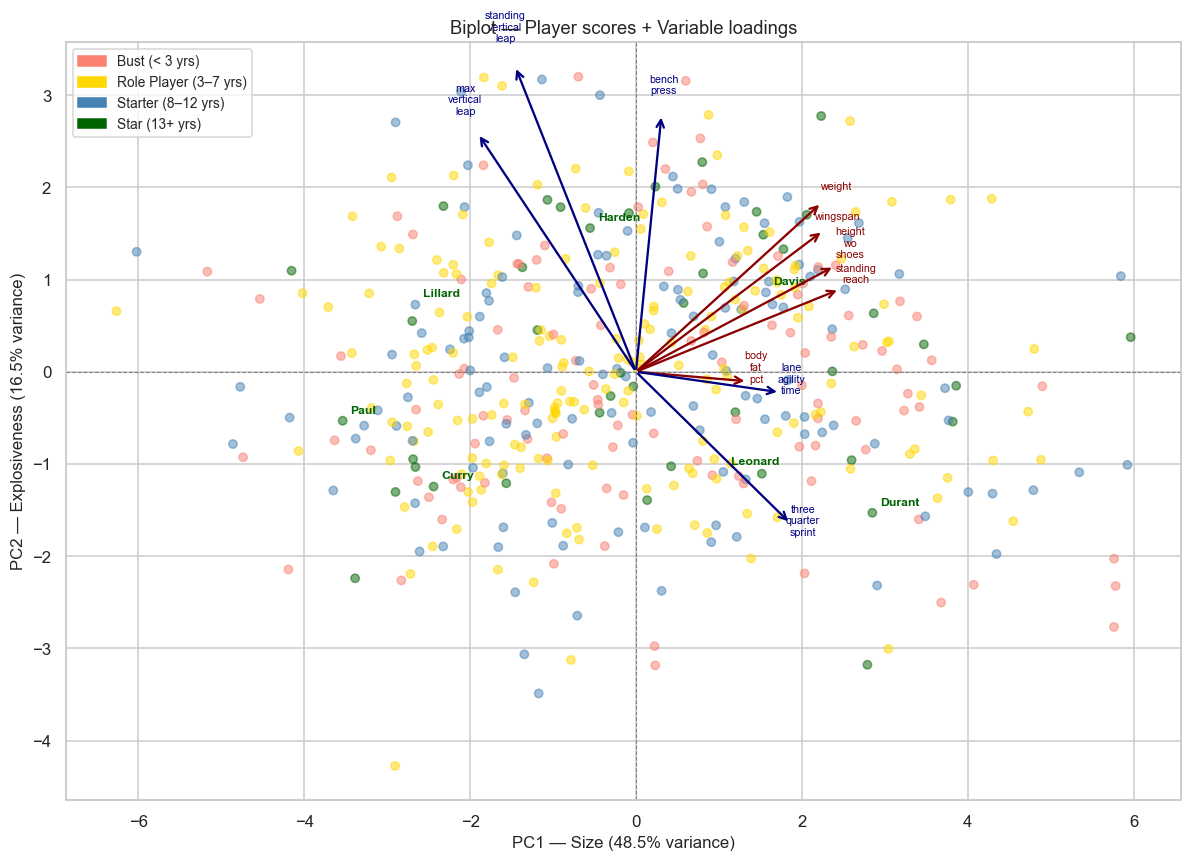

Saved: biplot.png


In [16]:
import matplotlib.patches as mpatches

def career_colour(yrs):
    if   yrs <  3: return 'salmon'
    elif yrs <  8: return 'gold'
    elif yrs < 13: return 'steelblue'
    else:          return 'darkgreen'

colours = [career_colour(y) for y in scores_df['career_length']]

fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(scores_df['Size'], scores_df['Explosiveness'],
           c=colours, alpha=0.5, s=30, zorder=2)

# Label greatest-75 players
for _, row in scores_df[scores_df['greatest_75'] == 'Y'].iterrows():
    ax.annotate(row['player_name'].split()[-1],
                (row['Size'], row['Explosiveness']),
                fontsize=8, color='darkgreen', fontweight='bold',
                xytext=(5, 5), textcoords='offset points')

# Draw loading arrows
scale = 6
grp_colour = {'size':'darkred', 'ath':'navy'}
var_groups = [(v, 'size') for v in SIZE_VARS] + [(v, 'ath') for v in ATH_VARS]

VAR_LABELS = {
    'height_wo_shoes':        'Height (no shoes)',
    'weight':                 'Weight',
    'wingspan':               'Wingspan',
    'standing_reach':         'Standing Reach',
    'body_fat_pct':           'Body Fat %',
    'standing_vertical_leap': 'Standing Vert',
    'max_vertical_leap':      'Max Vert',
    'lane_agility_time':      'Lane Agility',
    'three_quarter_sprint':   '3/4 Sprint',
    'bench_press':            'Bench Press',
}
for var, grp in var_groups:
    xl = loadings.loc[var, 'PC1'] * scale
    yl = loadings.loc[var, 'PC2'] * scale
    ax.annotate('', xy=(xl, yl), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=grp_colour[grp], lw=1.5))
    ax.text(xl * 1.08, yl * 1.08, VAR_LABELS.get(var, var),
            fontsize=7, color=grp_colour[grp], ha='center')

ax.set_xlabel(f'PC1 — Size (48.5% variance)', fontsize=11)
ax.set_ylabel(f'PC2 — Explosiveness (16.5% variance)', fontsize=11)
ax.set_title('Biplot — Player scores + Variable loadings', fontsize=12)
ax.axhline(0, color='grey', lw=0.7, ls='--')
ax.axvline(0, color='grey', lw=0.7, ls='--')
ax.legend(handles=[
    mpatches.Patch(color='salmon',    label='Bust (< 3 yrs)'),
    mpatches.Patch(color='gold',      label='Role Player (3–7 yrs)'),
    mpatches.Patch(color='steelblue', label='Starter (8–12 yrs)'),
    mpatches.Patch(color='darkgreen', label='Star (13+ yrs)'),
], fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('outputs/biplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: biplot.png')

def simplify_pos(pos):
    if pd.isna(pos): return "Unknown"
    pos = str(pos).upper()
    primary = pos.split("-")[0]
    if   primary == "C":  return "Center"
    elif primary == "PF": return "Forward"
    elif primary == "SF": return "Forward"
    elif primary == "SG": return "Guard"
    elif primary == "PG": return "Guard"
    else: return "Unknown"

scores_df["pos_simple"] = scores_df["position"].apply(simplify_pos)

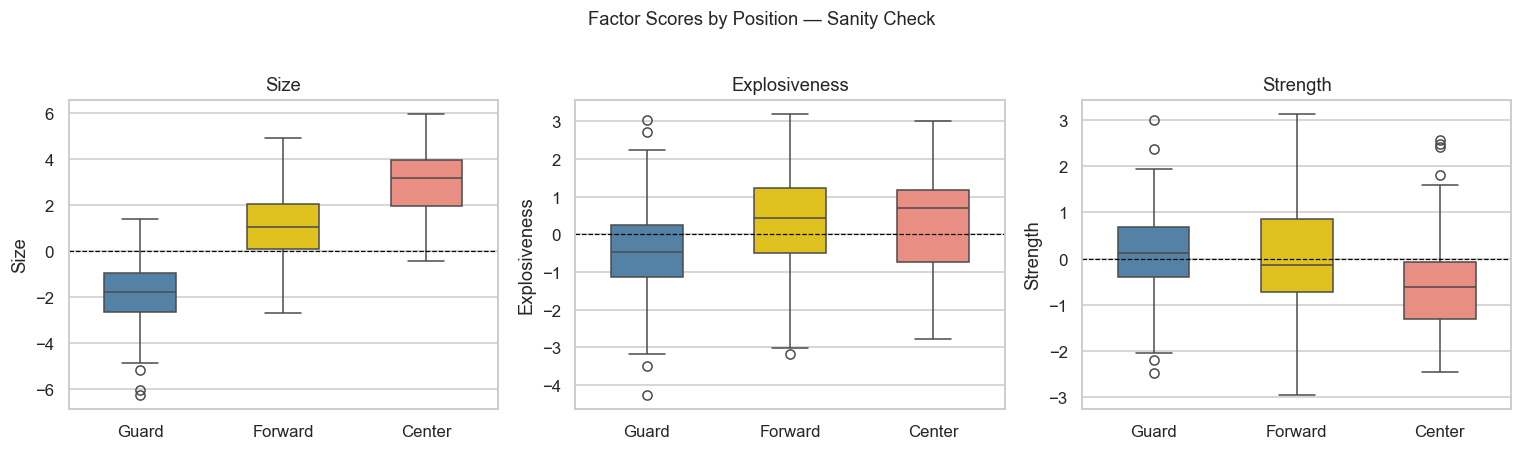

In [20]:
pos_order   = ['Guard', 'Forward', 'Center']
pos_palette = {'Guard':'steelblue', 'Forward':'gold', 'Center':'salmon'}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, factor in enumerate(['Size', 'Explosiveness', 'Strength']):
    plot_data = scores_df[scores_df['pos_simple'].isin(pos_order)]
    sns.boxplot(data=plot_data, x='pos_simple', y=factor,
                order=pos_order, palette=pos_palette,
                ax=axes[i], width=0.5)
    axes[i].set_title(factor)
    axes[i].set_xlabel('')
    axes[i].axhline(0, color='black', lw=0.8, ls='--')

plt.suptitle('Factor Scores by Position — Sanity Check', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('outputs/scores_by_position.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
print('scores_df columns:', list(scores_df.columns))

scores_df columns: ['Size', 'Explosiveness', 'Strength', 'player_name', 'career_length', 'overall_pick', 'position', 'greatest_75', 'pos_simple']


In [24]:
scores_df['organization_type'] = pca_df['organization_type'].values

export = scores_df[['player_name', 'Size', 'Explosiveness', 'Strength',
                     'career_length', 'overall_pick',
                     'organization_type', 'position', 'greatest_75']].copy()

out_path = Path('data') / 'pca_factor_scores.csv'
export.to_csv(out_path, index=False)

print(f'Saved: {out_path}')
print(f'Shape: {export.shape}')
print()
print(export.head(10).to_string(index=False))

Saved: C:\Users\Luc\.cache\kagglehub\datasets\wyattowalsh\basketball\versions\231\pca_factor_scores.csv
Shape: (472, 9)

          player_name      Size  Explosiveness  Strength  career_length  overall_pick  organization_type position greatest_75
       Gilbert Arenas -1.584587       0.156148 -0.026600           10.0            30 College/University       SG           N
    Brandon Armstrong -1.553446      -0.522830  0.346024            2.0            23 College/University       SG           N
        Shane Battier  0.925017       0.181337  0.941615           12.0             6 College/University    SF-PF           N
Ruben Boumtje-Boumtje  3.231861      -0.420784 -1.323846            2.0            49 College/University        C           N
      Michael Bradley  2.229417      -0.437615  0.908304            4.0            17 College/University       PF           N
       Jamison Brewer -1.865027      -1.280221  1.228692            3.0            40 College/University       PG          

## Part 2 — Linear Regression

Two OLS models predict career length from combine-derived factors.
**Model 1** includes `overall_pick` as a control; **Model 2** uses physical measurements alone.
The R² gap between models quantifies how much predictive value draft position adds beyond raw athleticism.

In [26]:
print('pca_df_age columns:', list(pca_df_age.columns))

pca_df_age columns: ['height_wo_shoes', 'weight', 'wingspan', 'standing_reach', 'body_fat_pct', 'standing_vertical_leap', 'max_vertical_leap', 'lane_agility_time', 'three_quarter_sprint', 'bench_press', 'player_name', 'career_length', 'overall_pick', 'organization_type', 'position', 'greatest_75_flag', 'person_id', 'birthdate']


In [27]:
# Get draft year from df using the same index
pca_df_age['draft_year'] = df.loc[pca_df_age.index, 'season'].values

print('Sample:')
print(pca_df_age[['player_name', 'birthdate', 'draft_year']].head(8).to_string(index=False))

Sample:
          player_name           birthdate  draft_year
       Gilbert Arenas 1982-01-06 00:00:00        2001
    Brandon Armstrong 1980-06-16 00:00:00        2001
        Shane Battier 1978-09-09 00:00:00        2001
Ruben Boumtje-Boumtje 1978-05-20 00:00:00        2001
      Michael Bradley 1979-04-18 00:00:00        2001
       Jamison Brewer 1980-11-19 00:00:00        2001
          Kwame Brown 1982-03-10 00:00:00        2001
       Tyson Chandler 1982-10-02 00:00:00        2001


In [28]:
# Parse birthdate and compute age at draft
pca_df_age['birthdate']  = pd.to_datetime(pca_df_age['birthdate'], errors='coerce')
pca_df_age['birth_year'] = pca_df_age['birthdate'].dt.year
pca_df_age['age_at_draft'] = pca_df_age['draft_year'] - pca_df_age['birth_year']

print(f'age_at_draft nulls: {pca_df_age["age_at_draft"].isna().sum()}')
print(f'\nAge at draft — min: {pca_df_age["age_at_draft"].min():.0f}, '
      f'max: {pca_df_age["age_at_draft"].max():.0f}, '
      f'mean: {pca_df_age["age_at_draft"].mean():.1f}')
print()
print('Distribution:')
print(pca_df_age['age_at_draft'].value_counts().sort_index().to_string())

age_at_draft nulls: 0

Age at draft — min: 17, max: 44, mean: 21.1

Distribution:
age_at_draft
17      3
18     10
19     70
20     84
21    107
22    109
23     67
24     19
25      1
27      1
44      1


In [29]:
# The age 44 entry is a data error — drop anyone outside realistic draft age range
print('Players with suspicious ages:')
print(pca_df_age[pca_df_age['age_at_draft'] > 30][['player_name','birth_year','draft_year','age_at_draft']].to_string(index=False))

# Keep only realistic ages (17-30)
pca_df_age = pca_df_age[pca_df_age['age_at_draft'].between(17, 30)].copy()

print(f'\nPlayers remaining after age filter: {len(pca_df_age)}')
print(f'Age — min: {pca_df_age["age_at_draft"].min():.0f}, '
      f'max: {pca_df_age["age_at_draft"].max():.0f}, '
      f'mean: {pca_df_age["age_at_draft"].mean():.1f}')

Players with suspicious ages:
    player_name  birth_year  draft_year  age_at_draft
Reggie Williams        1964        2008            44

Players remaining after age filter: 471
Age — min: 17, max: 27, mean: 21.1


In [30]:
# Add age_at_draft to scores_df using the same index
scores_df['age_at_draft'] = pca_df_age['age_at_draft']

# Update export with age_at_draft included
export = scores_df[['player_name', 'Size', 'Explosiveness', 'Strength',
                     'career_length', 'overall_pick', 'age_at_draft',
                     'organization_type', 'position', 'greatest_75']].copy()

# Drop the one player we filtered out (Reggie Williams)
export = export.dropna(subset=['age_at_draft'])

print(f'Export shape: {export.shape}')
print(f'Nulls:\n{export.isna().sum().to_string()}')
print()
print(export.head(5).to_string(index=False))

Export shape: (459, 10)
Nulls:
player_name          0
Size                 0
Explosiveness        0
Strength             0
career_length        0
overall_pick         0
age_at_draft         0
organization_type    0
position             1
greatest_75          0

          player_name      Size  Explosiveness  Strength  career_length  overall_pick  age_at_draft  organization_type position greatest_75
       Gilbert Arenas -1.584587       0.156148 -0.026600           10.0            30          19.0 College/University       SG           N
    Brandon Armstrong -1.553446      -0.522830  0.346024            2.0            23          21.0 College/University       SG           N
        Shane Battier  0.925017       0.181337  0.941615           12.0             6          23.0 College/University    SF-PF           N
Ruben Boumtje-Boumtje  3.231861      -0.420784 -1.323846            2.0            49          23.0 College/University        C           N
      Michael Bradley  2.229417      -

In [31]:
export = export.dropna(subset=['position'])
print(f'Final shape: {export.shape}')

out_path = Path('data') / 'pca_factor_scores.csv'
export.to_csv(out_path, index=False)
print(f'Saved: {out_path}')

Final shape: (458, 10)
Saved: C:\Users\Luc\.cache\kagglehub\datasets\wyattowalsh\basketball\versions\231\pca_factor_scores.csv


### Model 1 — Full Model (with Draft Pick)

Predictors: Size (PC1), Explosiveness (PC2), Strength (PC3), Age at Draft, Overall Pick, Organization Type, Position.  
Reference categories: College/University (org), Guard (position).

In [32]:
import statsmodels.api as sm

print('statsmodels imported successfully')
print('\norganization_type values:')
print(export['organization_type'].value_counts().to_string())

statsmodels imported successfully

organization_type values:
organization_type
College/University    430
Other Team/Club        15
High School            13


In [33]:
# Simplify position (reuse the same function as before)
def simplify_pos(pos):
    if pd.isna(pos): return 'Unknown'
    pos = str(pos).upper()
    primary = pos.split('-')[0]
    if   primary == 'C':  return 'Center'
    elif primary == 'PF': return 'Forward'
    elif primary == 'SF': return 'Forward'
    elif primary == 'SG': return 'Guard'
    elif primary == 'PG': return 'Guard'
    else: return 'Unknown'

export['pos_simple'] = export['position'].apply(simplify_pos)

print('Simplified position counts:')
print(export['pos_simple'].value_counts().to_string())
print('\norganization_type counts:')
print(export['organization_type'].value_counts().to_string())

Simplified position counts:
pos_simple
Guard      210
Forward    198
Center      50

organization_type counts:
organization_type
College/University    430
Other Team/Club        15
High School            13


In [34]:
# Dummy code organization_type — reference = College/University (dropped)
org_dummies = pd.get_dummies(export['organization_type'], prefix='org', drop_first=False)
org_dummies = org_dummies.drop(columns=['org_College/University'])
print('Organization dummies created:', list(org_dummies.columns))

# Dummy code position — reference = Guard (dropped)
pos_dummies = pd.get_dummies(export['pos_simple'], prefix='pos', drop_first=False)
pos_dummies = pos_dummies.drop(columns=['pos_Guard'])
print('Position dummies created:    ', list(pos_dummies.columns))

# Assemble the full predictor matrix
X_full = pd.concat([
    export[['Size', 'Explosiveness', 'Strength', 'age_at_draft', 'overall_pick']],
    org_dummies,
    pos_dummies
], axis=1)

y = export['career_length']

print(f'\nPredictor matrix shape: {X_full.shape}')
print(f'Outcome variable shape: {y.shape}')
print(f'\nColumns:\n{list(X_full.columns)}')

Organization dummies created: ['org_High School', 'org_Other Team/Club']
Position dummies created:     ['pos_Center', 'pos_Forward']

Predictor matrix shape: (458, 9)
Outcome variable shape: (458,)

Columns:
['Size', 'Explosiveness', 'Strength', 'age_at_draft', 'overall_pick', 'org_High School', 'org_Other Team/Club', 'pos_Center', 'pos_Forward']


In [36]:
X_full = X_full.astype(float)
X1 = sm.add_constant(X_full)
model1 = sm.OLS(y, X1).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:          career_length   R-squared:                       0.307
Model:                            OLS   Adj. R-squared:                  0.293
Method:                 Least Squares   F-statistic:                     22.08
Date:                Sat, 23 May 2026   Prob (F-statistic):           4.89e-31
Time:                        19:16:09   Log-Likelihood:                -1242.0
No. Observations:                 458   AIC:                             2504.
Df Residuals:                     448   BIC:                             2545.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   9.5854    

### Model 2 — Restricted Model (Combine Factors Only)

Same specification as Model 1 with `overall_pick` removed.
The drop in R² directly measures the marginal contribution of draft position to career length prediction.

In [37]:
X2 = X_full.drop(columns=['overall_pick'])
X2 = sm.add_constant(X2)
model2 = sm.OLS(y, X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:          career_length   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     3.119
Date:                Sat, 23 May 2026   Prob (F-statistic):            0.00193
Time:                        19:17:33   Log-Likelihood:                -1313.7
No. Observations:                 458   AIC:                             2645.
Df Residuals:                     449   BIC:                             2683.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   5.0949    

### Model Comparison

R², Adj. R², F-statistic, and AIC compared side-by-side.

In [38]:
print("=" * 55)
print(f"{'Model Comparison':^55}")
print("=" * 55)
print(f"{'Metric':<30} {'Model 1':>10} {'Model 2':>10}")
print(f"{'(with overall_pick)':<30} {'':>10} {'(w/o pick)':>10}")
print("-" * 55)
print(f"{'R-squared':<30} {model1.rsquared:>10.3f} {model2.rsquared:>10.3f}")
print(f"{'Adj. R-squared':<30} {model1.rsquared_adj:>10.3f} {model2.rsquared_adj:>10.3f}")
print(f"{'F-statistic':<30} {model1.fvalue:>10.2f} {model2.fvalue:>10.3f}")
print(f"{'AIC':<30} {model1.aic:>10.0f} {model2.aic:>10.0f}")
print("=" * 55)
print(f"\nR² drop when pick removed: {model1.rsquared - model2.rsquared:.3f} ({(model1.rsquared - model2.rsquared)/model1.rsquared*100:.1f}% of Model 1's R²)")
print(f"AIC increase (worse fit):  +{model2.aic - model1.aic:.0f} points")

                   Model Comparison                    
Metric                            Model 1    Model 2
(with overall_pick)                       (w/o pick)
-------------------------------------------------------
R-squared                           0.307      0.053
Adj. R-squared                      0.293      0.036
F-statistic                         22.08      3.119
AIC                                  2504       2645

R² drop when pick removed: 0.254 (82.7% of Model 1's R²)
AIC increase (worse fit):  +141 points


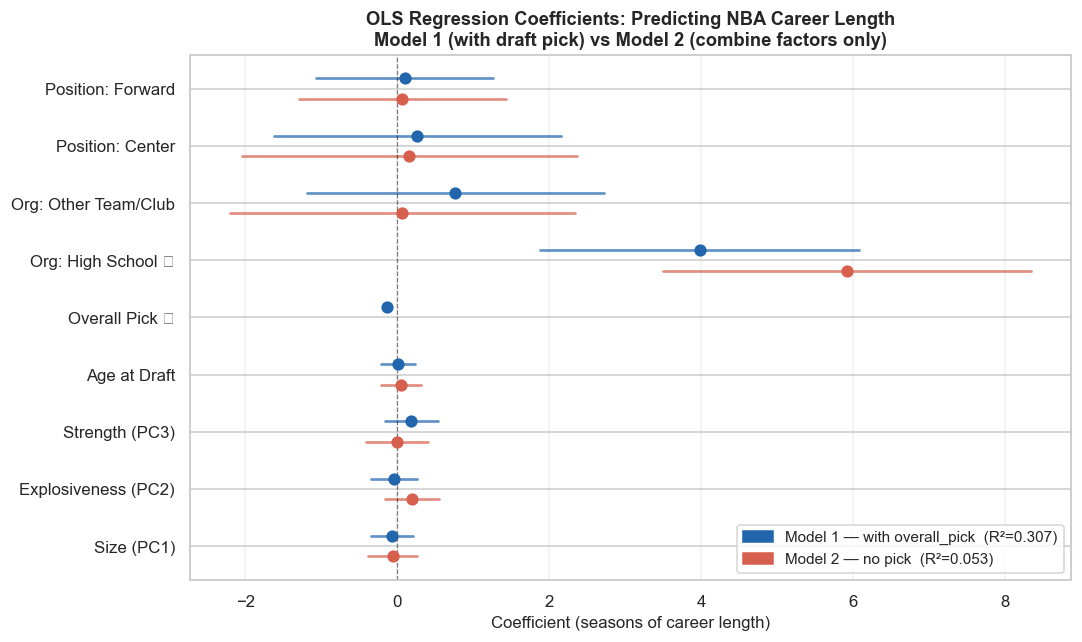

Saved: regression_coef_plot.png


In [39]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- Extract coefficients and CIs (excluding const) ---
def get_coef_df(model, label):
    coefs = model.params.drop('const')
    ci = model.conf_int().drop('const')
    return pd.DataFrame({
        'variable': coefs.index,
        'coef': coefs.values,
        'ci_lo': ci[0].values,
        'ci_hi': ci[1].values,
        'model': label
    })

m1_df = get_coef_df(model1, 'Model 1 (with pick)')
m2_df = get_coef_df(model2, 'Model 2 (no pick)')

# Merge on variable for side-by-side plotting
vars_order = ['Size', 'Explosiveness', 'Strength', 'age_at_draft',
              'overall_pick', 'org_High School', 'org_Other Team/Club',
              'pos_Center', 'pos_Forward']

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(vars_order))
offset = 0.18  # vertical offset between model dots

colors = {'Model 1 (with pick)': '#2166ac', 'Model 2 (no pick)': '#d6604d'}

for i, var in enumerate(vars_order):
    for j, (df, shift) in enumerate([(m1_df, offset), (m2_df, -offset)]):
        row = df[df['variable'] == var]
        if row.empty:
            # overall_pick doesn't exist in model 2
            continue
        c = row['coef'].values[0]
        lo = row['ci_lo'].values[0]
        hi = row['ci_hi'].values[0]
        color = colors[row['model'].values[0]]
        yp = i + shift
        ax.plot([lo, hi], [yp, yp], color=color, linewidth=1.8, alpha=0.7)
        ax.plot(c, yp, 'o', color=color, markersize=7, zorder=5)

# Reference line at 0
ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

# Labels
ax.set_yticks(y_pos)
ax.set_yticklabels([
    'Size (PC1)', 'Explosiveness (PC2)', 'Strength (PC3)',
    'Age at Draft', 'Overall Pick ★',
    'Org: High School ★', 'Org: Other Team/Club',
    'Position: Center', 'Position: Forward'
], fontsize=11)

ax.set_xlabel('Coefficient (seasons of career length)', fontsize=11)
ax.set_title('OLS Regression Coefficients: Predicting NBA Career Length\n'
             'Model 1 (with draft pick) vs Model 2 (combine factors only)',
             fontsize=12, fontweight='bold')

patch1 = mpatches.Patch(color='#2166ac', label='Model 1 — with overall_pick  (R²=0.307)')
patch2 = mpatches.Patch(color='#d6604d', label='Model 2 — no pick  (R²=0.053)')
ax.legend(handles=[patch1, patch2], loc='lower right', fontsize=10)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('regression_coef_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: regression_coef_plot.png")

In [40]:
summary_rows = []
var_labels = {
    'Size':                 'Size (PC1)',
    'Explosiveness':        'Explosiveness (PC2)',
    'Strength':             'Strength (PC3)',
    'age_at_draft':         'Age at Draft',
    'overall_pick':         'Overall Pick',
    'org_High School':      'Org: High School',
    'org_Other Team/Club':  'Org: Other Team/Club',
    'pos_Center':           'Position: Center',
    'pos_Forward':          'Position: Forward',
}

for var, label in var_labels.items():
    row = {'Variable': label}
    if var in model1.params:
        row['M1 Coef'] = round(model1.params[var], 3)
        row['M1 p']    = round(model1.pvalues[var], 3)
    else:
        row['M1 Coef'] = '—'
        row['M1 p']    = '—'
    if var in model2.params:
        row['M2 Coef'] = round(model2.params[var], 3)
        row['M2 p']    = round(model2.pvalues[var], 3)
    else:
        row['M2 Coef'] = '—'
        row['M2 p']    = '—'
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
print(f"\nModel 1 R²={0.307}, Adj-R²={0.293} | Model 2 R²={0.053}, Adj-R²={0.036}")

            Variable  M1 Coef  M1 p M2 Coef   M2 p
          Size (PC1)   -0.070 0.619  -0.064  0.699
 Explosiveness (PC2)   -0.042 0.785   0.195  0.278
      Strength (PC3)    0.183 0.299  -0.006  0.976
        Age at Draft    0.010 0.928   0.043  0.749
        Overall Pick   -0.140 0.000       —      —
    Org: High School    3.979 0.000   5.923    0.0
Org: Other Team/Club    0.763 0.443   0.068  0.954
    Position: Center    0.261 0.786   0.157  0.889
   Position: Forward    0.096 0.872   0.065  0.926

Model 1 R²=0.307, Adj-R²=0.293 | Model 2 R²=0.053, Adj-R²=0.036


---

## Part 3 — Extended Analysis

Beyond the core project scope: a **prospect scoring tool** built from PCA loadings, **K-Means clustering** to identify physical archetypes, and a **dark horse / bust detector** using career surplus relative to pick-based expectations.

In [46]:
export['elite'] = (export['greatest_75'] == 'Y').astype(int)
print(f"Elite players: {export['elite'].sum()} / {len(export)} ({export['elite'].mean():.1%})")
print("\nElite players in our dataset:")
print(export[export['elite'] == 1][['player_name', 'Size', 'Explosiveness', 'Strength', 'overall_pick', 'career_length']])

Elite players: 7 / 458 (1.5%)

Elite players in our dataset:
        player_name      Size  Explosiveness  Strength  overall_pick  \
79       Chris Paul -3.536036      -0.531219  0.643143             4   
97     Kevin Durant  2.849580      -1.529130 -2.224633             2   
146   Stephen Curry -2.439931      -1.244583  0.505308             7   
157    James Harden -0.553259       1.557872  1.566540             3   
223   Kawhi Leonard  1.052528      -1.086016 -1.131241            15   
251   Anthony Davis  1.565933       0.859948 -0.610034             1   
268  Damian Lillard -2.659963       0.728010  0.128627             6   

     career_length  
79            18.0  
97            16.0  
146           14.0  
157           14.0  
223           12.0  
251           11.0  
268           11.0  


In [47]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ── Rebuild PCA from scratch using the same data ──────────────────────────
combine = pd.read_csv(r'C:\Users\Luc\.cache\kagglehub\datasets\wyattowalsh\basketball\versions\231\csv\draft_combine_stats.csv')

SIZE_VARS = ['height_wo_shoes', 'weight', 'wingspan', 'standing_reach', 'body_fat_pct']
ATH_VARS  = ['standing_vertical_leap', 'max_vertical_leap', 'lane_agility_time',
             'three_quarter_sprint', 'bench_press']
USED_VARS = SIZE_VARS + ATH_VARS

combine_clean = combine[USED_VARS].dropna()

scaler = StandardScaler()
scaler.fit(combine_clean)                   # fit scaler on full combine data
X_scaled = scaler.transform(combine_clean)

pca = PCA(n_components=3)
pca.fit(X_scaled)                           # fit PCA on full combine data

print("PCA refitted on", len(combine_clean), "players")
print(f"Variance explained: {pca.explained_variance_ratio_.cumsum()[-1]:.1%}")

PCA refitted on 704 players
Variance explained: 78.6%


In [48]:
def score_prospect(player_name, height_wo_shoes, weight, wingspan,
                   standing_reach, body_fat_pct, standing_vertical_leap,
                   max_vertical_leap, lane_agility_time,
                   three_quarter_sprint, bench_press,
                   projected_pick=None):
    """
    Score an NBA draft prospect from raw combine measurements.
    Returns their physical factor scores and a career length estimate.
    """
    raw = np.array([[height_wo_shoes, weight, wingspan, standing_reach,
                     body_fat_pct, standing_vertical_leap, max_vertical_leap,
                     lane_agility_time, three_quarter_sprint, bench_press]])

    scaled   = scaler.transform(raw)
    factors  = pca.transform(scaled)[0]

    size_score  = round(factors[0], 2)
    expl_score  = round(factors[1], 2)
    str_score   = round(factors[2], 2)

    def label(val):
        if   val >  1.5: return "Elite"
        elif val >  0.5: return "Above Avg"
        elif val > -0.5: return "Average"
        elif val > -1.5: return "Below Avg"
        else:            return "Low"

    # Career estimate using Model 1 coefficients (intercept + factors + pick)
    pick_effect = -0.140 * projected_pick if projected_pick else 0
    predicted_career = 9.585 + (-0.070 * size_score) + (-0.042 * expl_score) \
                       + (0.183 * str_score) + pick_effect

    print("=" * 52)
    print(f"  PROSPECT REPORT: {player_name}")
    print("=" * 52)
    print(f"  {'Factor':<18} {'Score':>7}   {'Rating'}")
    print(f"  {'-'*40}")
    print(f"  {'Size (PC1)':<18} {size_score:>7.2f}   {label(size_score)}")
    print(f"  {'Explosiveness (PC2)':<18} {expl_score:>7.2f}   {label(expl_score)}")
    print(f"  {'Strength (PC3)':<18} {str_score:>7.2f}   {label(str_score)}")
    print(f"  {'-'*40}")
    if projected_pick:
        print(f"  Projected pick:       #{projected_pick}")
        print(f"  Predicted career:     {predicted_career:.1f} seasons")
    else:
        print(f"  Predicted career:     {predicted_career:.1f} seasons (no pick context)")
    print("=" * 52)

    return {'name': player_name, 'Size': size_score,
            'Explosiveness': expl_score, 'Strength': str_score,
            'predicted_career': round(predicted_career, 1)}

# Test - Kevin Durant #
kd_row = combine[combine['player_name'].str.contains('Durant', na=False)].iloc[0]
print("Durant's raw measurements:")
print(kd_row[USED_VARS])

Durant's raw measurements:
height_wo_shoes            81.0
weight                    215.0
wingspan                  88.75
standing_reach            110.0
body_fat_pct                6.6
standing_vertical_leap     26.0
max_vertical_leap          33.5
lane_agility_time         12.33
three_quarter_sprint       3.45
bench_press                 0.0
Name: 256, dtype: object


In [49]:
result = score_prospect(
    player_name          = "Kevin Durant",
    height_wo_shoes      = 81.0,
    weight               = 215.0,
    wingspan             = 88.75,
    standing_reach       = 110.0,
    body_fat_pct         = 6.6,
    standing_vertical_leap = 26.0,
    max_vertical_leap    = 33.5,
    lane_agility_time    = 12.33,
    three_quarter_sprint = 3.45,
    bench_press          = 0.0,
    projected_pick       = 2
)
results = {0: result}


  PROSPECT REPORT: Kevin Durant
  Factor               Score   Rating
  ----------------------------------------
  Size (PC1)            2.51   Elite
  Explosiveness (PC2)   -0.52   Below Avg
  Strength (PC3)       -2.56   Low
  ----------------------------------------
  Projected pick:       #2
  Predicted career:     8.7 seasons


In [55]:
# Stephen Curry #
sc_row = combine[combine['player_name'] == 'Stephen Curry'].iloc[0]
r_curry = score_prospect(
    player_name            = "Stephen Curry",
    height_wo_shoes        = sc_row['height_wo_shoes'],
    weight                 = sc_row['weight'],
    wingspan               = sc_row['wingspan'],
    standing_reach         = sc_row['standing_reach'],
    body_fat_pct           = sc_row['body_fat_pct'],
    standing_vertical_leap = sc_row['standing_vertical_leap'],
    max_vertical_leap      = sc_row['max_vertical_leap'],
    lane_agility_time      = sc_row['lane_agility_time'],
    three_quarter_sprint   = sc_row['three_quarter_sprint'],
    bench_press            = sc_row['bench_press'],
    projected_pick         = 7
)


results[1] = r_curry

  PROSPECT REPORT: Stephen Curry
  Factor               Score   Rating
  ----------------------------------------
  Size (PC1)           -2.45   Low
  Explosiveness (PC2)   -1.19   Below Avg
  Strength (PC3)        0.29   Average
  ----------------------------------------
  Projected pick:       #7
  Predicted career:     8.9 seasons


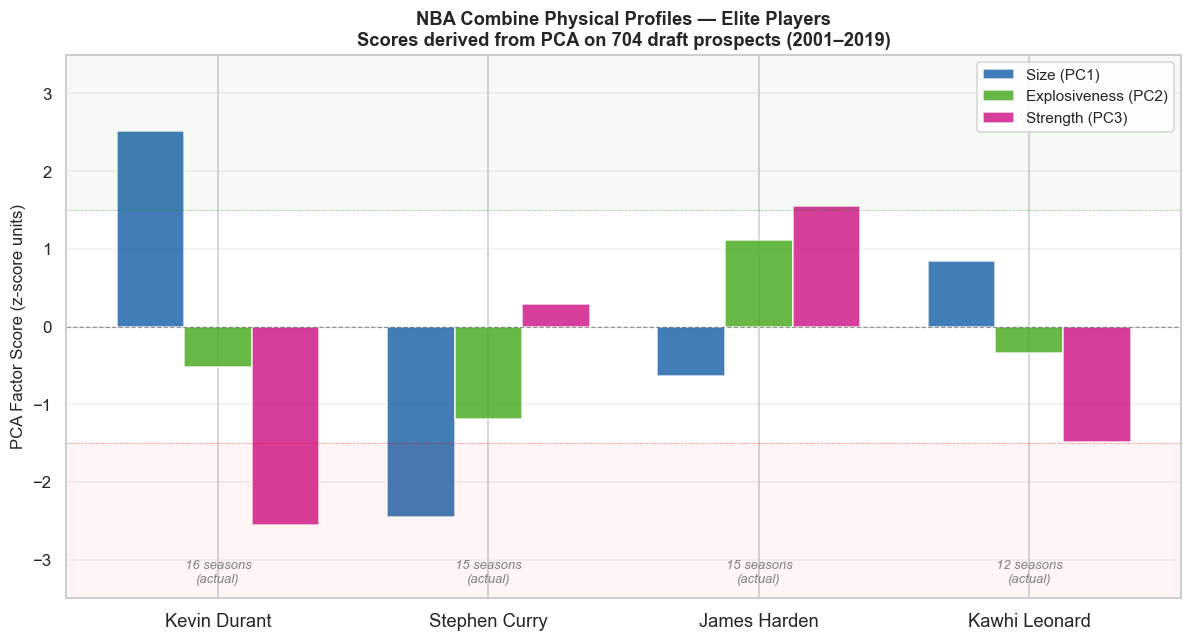

Saved: elite_prospect_profiles.png


In [56]:
import matplotlib.pyplot as plt
import numpy as np

players_plot = [result, r_curry, results[2], results[3]]  # Durant, Curry, Harden, Kawhi
names   = [r['name'] for r in players_plot]
size_s  = [r['Size'] for r in players_plot]
expl_s  = [r['Explosiveness'] for r in players_plot]
str_s   = [r['Strength'] for r in players_plot]

x = np.arange(len(names))
w = 0.25

fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - w, size_s,  w, label='Size (PC1)',          color='#2166ac', alpha=0.85)
b2 = ax.bar(x,     expl_s,  w, label='Explosiveness (PC2)', color='#4dac26', alpha=0.85)
b3 = ax.bar(x + w, str_s,   w, label='Strength (PC3)',      color='#d01c8b', alpha=0.85)

# Reference bands
ax.axhspan( 1.5,  4.0, color='green', alpha=0.04)
ax.axhspan(-4.0, -1.5, color='red',   alpha=0.04)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.axhline( 1.5, color='green', linewidth=0.6, linestyle=':', alpha=0.5)
ax.axhline(-1.5, color='red',   linewidth=0.6, linestyle=':', alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=12)
ax.set_ylabel('PCA Factor Score (z-score units)', fontsize=11)
ax.set_title('NBA Combine Physical Profiles — Elite Players\n'
             'Scores derived from PCA on 704 draft prospects (2001–2019)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(-3.5, 3.5)

# Annotate actual career lengths
actual = {'Kevin Durant': 16, 'Stephen Curry': 15, 'James Harden': 15, 'Kawhi Leonard': 12}
for i, name in enumerate(names):
    ax.text(i, -3.3, f"{actual[name]} seasons\n(actual)", ha='center',
            fontsize=8.5, color='gray', style='italic')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/elite_prospect_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: elite_prospect_profiles.png")

### Dark Horse Detection

A pick-only baseline model estimates expected career length for each draft slot.
Players with large positive residuals (actual − expected) outperformed their slot; top-15 picks with strong physical profiles and short careers are flagged as busts.

In [58]:
# ── Flip the model: career_length ~ overall_pick only ────────────────────
pick_only = sm.OLS(export['career_length'],
                   sm.add_constant(export['overall_pick'])).fit()

export['expected_career_by_pick'] = pick_only.fittedvalues
export['career_surplus'] = export['career_length'] - export['expected_career_by_pick']

print("Pick-only model:")
print(f"  R² = {pick_only.rsquared:.3f}")
print(pick_only.summary().tables[1])

print("\nTop 15 players who OUTPERFORMED their draft slot:")
print(export[['player_name','overall_pick','career_length',
              'expected_career_by_pick','career_surplus',
              'Size','Explosiveness','Strength']]
      .sort_values('career_surplus', ascending=False)
      .head(15).to_string(index=False))

Pick-only model:
  R² = 0.284
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           10.1219      0.338     29.915      0.000       9.457      10.787
overall_pick    -0.1440      0.011    -13.438      0.000      -0.165      -0.123

Top 15 players who OUTPERFORMED their draft slot:
   player_name  overall_pick  career_length  expected_career_by_pick  career_surplus      Size  Explosiveness  Strength
  Trevor Ariza            43           17.0                 3.929638       13.070362  1.197935      -0.438370 -0.555231
   Joe Johnson            10           20.0                 8.681864       11.318136  0.574045       0.745006 -0.349443
   Danny Green            46           14.0                 3.497617       10.502383 -0.031644      -0.158982  0.375180
DeAndre Jordan            35           15.0                 5.081693        9.918307  3.860001      -0.151366 -0.94

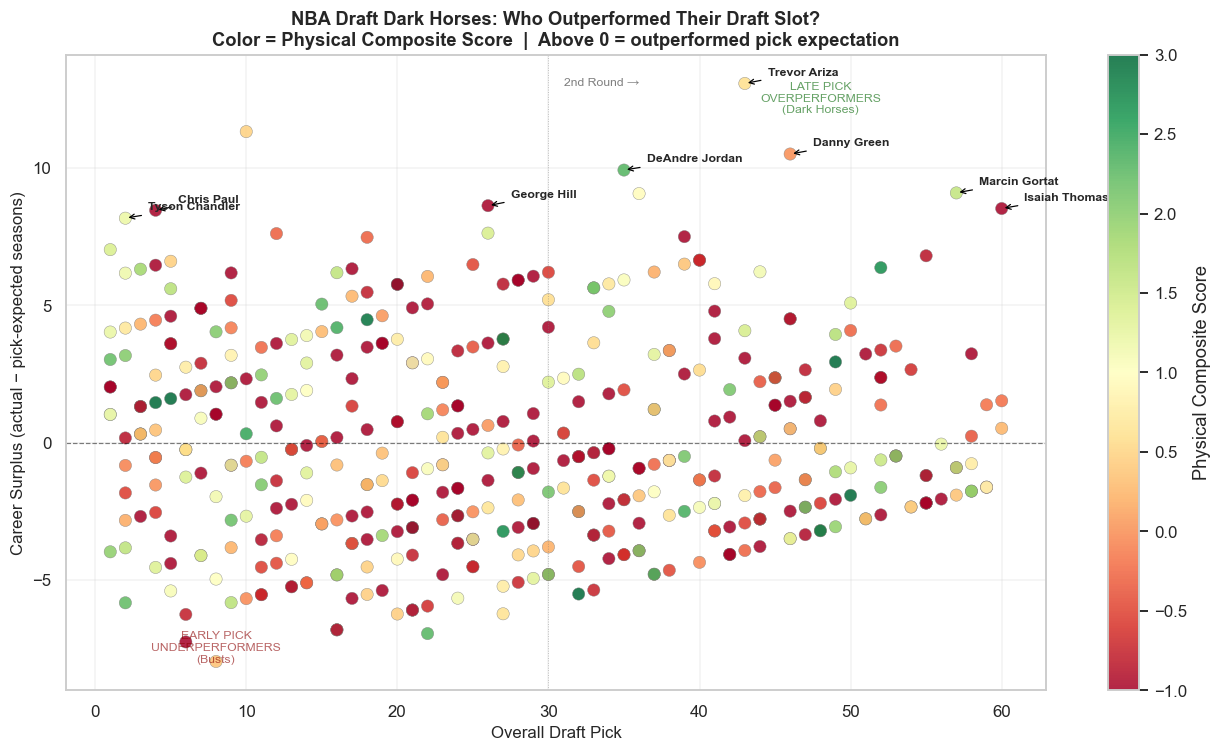

In [60]:
fig, ax = plt.subplots(figsize=(12, 7))

sc = ax.scatter(export['overall_pick'], export['career_surplus'],
                c=export['physical_composite'], cmap='RdYlGn',
                alpha=0.85, s=65, edgecolors='grey', linewidths=0.3,
                vmin=-1, vmax=3)          # tighter range = more saturated ends

plt.colorbar(sc, ax=ax, label='Physical Composite Score')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axvline(30, color='gray', linewidth=0.6, linestyle=':', alpha=0.5)
ax.text(31, ax.get_ylim()[1]*0.92, '2nd Round →', fontsize=8, color='gray')

label_players = {
    'Trevor Ariza':    (43, 13.07),
    'DeAndre Jordan':  (35,  9.92),
    'Marcin Gortat':   (57,  9.09),
    'Isaiah Thomas':   (60,  8.52),
    'Danny Green':     (46, 10.50),
    'George Hill':     (26,  8.62),
    'Chris Paul':      (4,   8.45),
    'Tyson Chandler':  (2,   8.17),
}

for name, (pick, surplus) in label_players.items():
    ax.annotate(name, xy=(pick, surplus),
                xytext=(pick + 1.5, surplus + 0.3),
                fontsize=8, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

ax.set_xlabel('Overall Draft Pick', fontsize=11)
ax.set_ylabel('Career Surplus (actual − pick-expected seasons)', fontsize=11)
ax.set_title('NBA Draft Dark Horses: Who Outperformed Their Draft Slot?\n'
             'Color = Physical Composite Score  |  Above 0 = outperformed pick expectation',
             fontsize=12, fontweight='bold')

ax.text(48, 12, 'LATE PICK\nOVERPERFORMERS\n(Dark Horses)', fontsize=8,
        color='darkgreen', alpha=0.6, ha='center')
ax.text(8, -8, 'EARLY PICK\nUNDERPERFORMERS\n(Busts)', fontsize=8,
        color='darkred', alpha=0.6, ha='center')

ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('dark_horse_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### Physical Archetype Clustering — K-Means

K-Means groups the 458 players into distinct physical profiles using the three PCA factor scores.
Optimal k selected via elbow method and silhouette score.

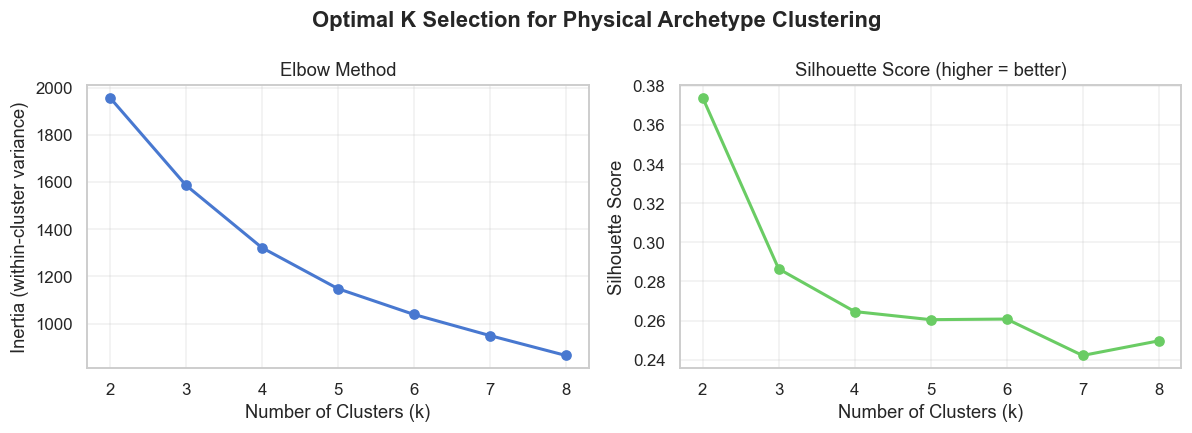


Silhouette scores:
  k=2: 0.374
  k=3: 0.286
  k=4: 0.265
  k=5: 0.260
  k=6: 0.261
  k=7: 0.242
  k=8: 0.250


In [61]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_clust = export[['Size', 'Explosiveness', 'Strength']].values

inertias, silhouettes = [], []
K = range(2, 9)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(list(K), inertias, 'bo-', linewidth=2)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (within-cluster variance)')
ax1.set_title('Elbow Method')
ax1.grid(alpha=0.3)

ax2.plot(list(K), silhouettes, 'go-', linewidth=2)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score (higher = better)')
ax2.grid(alpha=0.3)

plt.suptitle('Optimal K Selection for Physical Archetype Clustering', fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_selection.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSilhouette scores:")
for k, s in zip(K, silhouettes):
    print(f"  k={k}: {s:.3f}")

In [62]:
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
export['archetype'] = km_final.fit_predict(X_clust)

# Look at cluster centroids to label them
centroids = pd.DataFrame(km_final.cluster_centers_,
                         columns=['Size', 'Explosiveness', 'Strength'])
centroids['n_players'] = export['archetype'].value_counts().sort_index().values
centroids['avg_career'] = [export[export['archetype']==i]['career_length'].mean()
                           for i in range(4)]
print("Cluster centroids:")
print(centroids.round(3))

Cluster centroids:
    Size  Explosiveness  Strength  n_players  avg_career
0  0.942          1.255    -0.106        122       6.689
1 -0.722         -0.949    -0.150        141       5.723
2 -2.623          0.357     0.178        108       6.435
3  3.152         -0.606     0.235         87       6.092


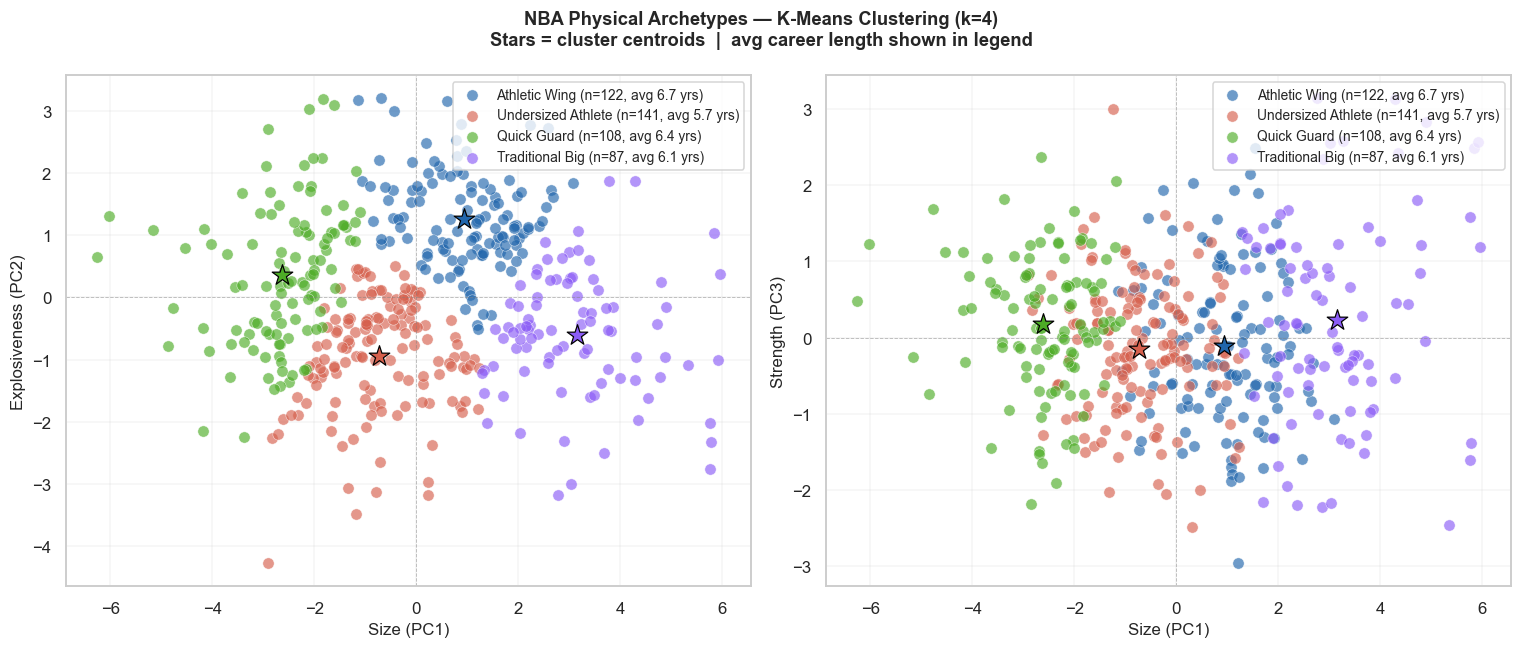

                    n_players  avg_career  avg_pick  pct_elite
archetype_name                                                
Athletic Wing             122        6.69     24.39       1.64
Quick Guard               108        6.44     28.17       2.78
Traditional Big            87        6.09     28.41       1.15
Undersized Athlete        141        5.72     27.84       0.71


In [63]:
archetype_names = {
    0: 'Athletic Wing',       # big + explosive
    1: 'Undersized Athlete',  # below avg all round
    2: 'Quick Guard',         # small but agile
    3: 'Traditional Big'      # elite size, low bounce
}
archetype_colors = {
    0: '#2166ac',   # blue
    1: '#d6604d',   # red
    2: '#4dac26',   # green
    3: '#8B5CF6'    # purple
}

export['archetype_name'] = export['archetype'].map(archetype_names)

# ── 2D scatter: Size vs Explosiveness, colored by archetype ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (xvar, yvar, xlabel, ylabel) in zip(axes, [
    ('Size', 'Explosiveness', 'Size (PC1)', 'Explosiveness (PC2)'),
    ('Size', 'Strength',      'Size (PC1)', 'Strength (PC3)')
]):
    for cluster_id, name in archetype_names.items():
        mask = export['archetype'] == cluster_id
        sub  = export[mask]
        ax.scatter(sub[xvar], sub[yvar],
                   label=f"{name} (n={mask.sum()}, avg {sub['career_length'].mean():.1f} yrs)",
                   color=archetype_colors[cluster_id],
                   alpha=0.65, s=55, edgecolors='white', linewidths=0.4)
    # Plot centroids
    for cluster_id in range(4):
        cx = centroids.loc[cluster_id, xvar]
        cy = centroids.loc[cluster_id, yvar]
        ax.scatter(cx, cy, color=archetype_colors[cluster_id],
                   s=200, marker='*', edgecolors='black', linewidths=0.8, zorder=5)
    ax.axhline(0, color='grey', linewidth=0.6, linestyle='--', alpha=0.5)
    ax.axvline(0, color='grey', linewidth=0.6, linestyle='--', alpha=0.5)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(alpha=0.2)

axes[0].legend(fontsize=9, loc='upper right')
axes[1].legend(fontsize=9, loc='upper right')

fig.suptitle('NBA Physical Archetypes — K-Means Clustering (k=4)\n'
             'Stars = cluster centroids  |  avg career length shown in legend',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('archetype_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
summary = export.groupby('archetype_name').agg(
    n_players    = ('career_length', 'count'),
    avg_career   = ('career_length', 'mean'),
    avg_pick     = ('overall_pick',  'mean'),
    pct_elite    = ('greatest_75',   lambda x: (x == 'Y').mean() * 100)
).round(2)
print(summary.sort_values('avg_career', ascending=False))

### Bust Detector

Top-15 picks with above-average physical composite scores and careers under 5 seasons — prospects the combine valued highly that the NBA did not retain.

In [64]:
# ── Update scorer to include archetype label ──────────────────────────────
def get_archetype(size, explosiveness, strength):
    point = np.array([[size, explosiveness, strength]])
    cluster_id = km_final.predict(point)[0]
    return archetype_names[cluster_id]

# ── A: BUST DETECTOR ──────────────────────────────────────────────────────
# High pick investment + strong physical score + short career
busts = export[
    (export['overall_pick'] <= 15) &          # top-15 pick = major investment
    (export['physical_composite'] > 0.5) &    # physically gifted
    (export['career_length'] < 5)             # career under 5 seasons
].copy()

busts = busts.sort_values('career_surplus')   # worst underperformers first

print(f"Busts found (top-15 pick, strong body, <5 seasons): {len(busts)}\n")
print(busts[['player_name', 'overall_pick', 'physical_composite',
             'career_length', 'career_surplus', 'archetype_name',
             'Size', 'Explosiveness', 'Strength']]
      .to_string(index=False))

Busts found (top-15 pick, strong body, <5 seasons): 5

    player_name  overall_pick  physical_composite  career_length  career_surplus  archetype_name     Size  Explosiveness  Strength
Hasheem Thabeet             2            2.231725            4.0       -5.833919   Athletic Wing 3.085040       1.842533 -1.066773
   Rodney White             9            1.650385            3.0       -5.825871 Traditional Big 2.355154      -0.126909  1.192278
Thomas Robinson             5            1.084266            4.0       -5.401898   Athletic Wing 1.347901       1.312866 -0.477827
   Jaxson Hayes             8            1.013709            4.0       -4.969877 Traditional Big 2.163612      -0.464241 -1.947058
       Sean May            13            0.976798            4.0       -4.249843   Athletic Wing 1.195513       0.782272  0.278872


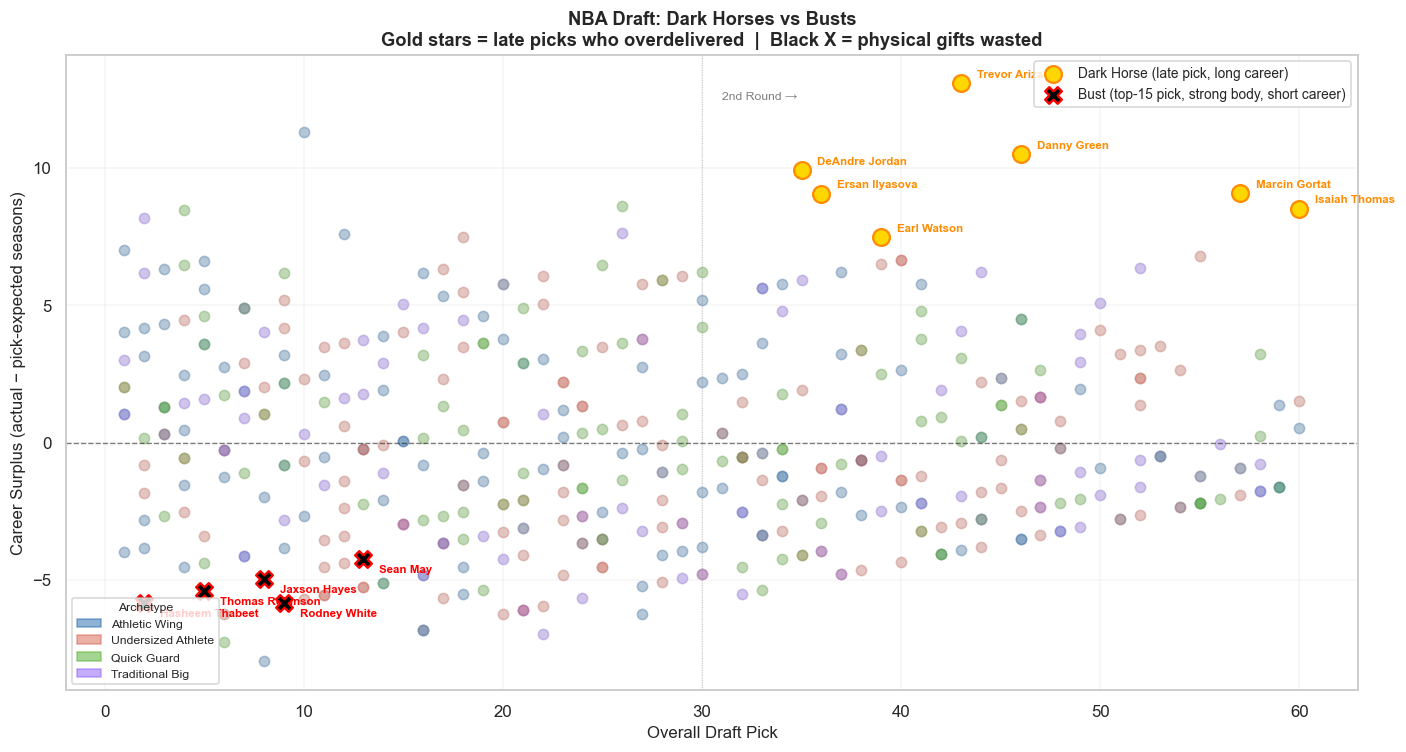

In [65]:
# Identify dark horses (late pick, long career surplus)
dark_horses = export[
    (export['overall_pick'] >= 30) &
    (export['career_surplus'] >= 7)
].copy()

fig, ax = plt.subplots(figsize=(13, 7))

# Background scatter — all players, grey
ax.scatter(export['overall_pick'], export['career_surplus'],
           color='lightgrey', alpha=0.5, s=45, zorder=1)

# Color by archetype for context
for cid, name in archetype_names.items():
    mask = export['archetype'] == cid
    ax.scatter(export.loc[mask, 'overall_pick'],
               export.loc[mask, 'career_surplus'],
               color=archetype_colors[cid], alpha=0.25, s=45, zorder=2)

# Highlight DARK HORSES
ax.scatter(dark_horses['overall_pick'], dark_horses['career_surplus'],
           color='gold', s=120, edgecolors='darkorange', linewidths=1.5,
           zorder=4, label='Dark Horse (late pick, long career)')

# Highlight BUSTS
ax.scatter(busts['overall_pick'], busts['career_surplus'],
           color='black', s=120, marker='X', edgecolors='red', linewidths=1.5,
           zorder=4, label='Bust (top-15 pick, strong body, short career)')

# Label dark horses
for _, row in dark_horses.iterrows():
    ax.annotate(row['player_name'],
                xy=(row['overall_pick'], row['career_surplus']),
                xytext=(row['overall_pick'] + 0.8, row['career_surplus'] + 0.2),
                fontsize=7.5, color='darkorange', fontweight='bold')

# Label busts
for _, row in busts.iterrows():
    ax.annotate(row['player_name'],
                xy=(row['overall_pick'], row['career_surplus']),
                xytext=(row['overall_pick'] + 0.8, row['career_surplus'] - 0.5),
                fontsize=7.5, color='red', fontweight='bold')

ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax.axvline(30, color='gray', linewidth=0.6, linestyle=':', alpha=0.5)
ax.text(31, 12.5, '2nd Round →', fontsize=8, color='gray')

ax.set_xlabel('Overall Draft Pick', fontsize=11)
ax.set_ylabel('Career Surplus (actual − pick-expected seasons)', fontsize=11)
ax.set_title('NBA Draft: Dark Horses vs Busts\n'
             'Gold stars = late picks who overdelivered  |  Black X = physical gifts wasted',
             fontsize=12, fontweight='bold')

# Archetype legend patches
import matplotlib.patches as mpatches
arch_patches = [mpatches.Patch(color=archetype_colors[i], alpha=0.5,
                label=archetype_names[i]) for i in range(4)]
leg1 = ax.legend(handles=arch_patches, loc='lower left', fontsize=8,
                 title='Archetype', title_fontsize=8)
ax.add_artist(leg1)
ax.legend(loc='upper right', fontsize=9)

ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('bust_vs_darkhorse.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Part 4 — 2026 Draft Class Scoring

The PCA framework trained on 2001–2019 data is applied to the 2026 combine class.
Missing athletic testing values are imputed at the historical mean (flagged with ⚠).
Scores reflect physical profile relative to all historical prospects, not 2026 peers alone.

In [66]:
# ── Get column means from our training data (for imputation) ─────────────
col_means = combine_clean.mean()
print("Column means for imputation:")
print(col_means.round(2))

Column means for imputation:
height_wo_shoes            77.51
weight                    215.82
wingspan                   82.43
standing_reach            103.39
body_fat_pct                7.34
standing_vertical_leap     29.24
max_vertical_leap          34.61
lane_agility_time          11.42
three_quarter_sprint        3.28
bench_press                10.16
dtype: float64


In [67]:
# ── Updated scorer: handles NaN inputs with mean imputation ──────────────
def score_prospect_v2(player_name, projected_pick,
                      height_wo_shoes=None, weight=None, wingspan=None,
                      standing_reach=None, body_fat_pct=None,
                      standing_vertical_leap=None, max_vertical_leap=None,
                      lane_agility_time=None, three_quarter_sprint=None,
                      bench_press=None):

    inputs = [height_wo_shoes, weight, wingspan, standing_reach, body_fat_pct,
              standing_vertical_leap, max_vertical_leap,
              lane_agility_time, three_quarter_sprint, bench_press]
    labels = USED_VARS
    imputed_flags = []

    filled = []
    for val, col in zip(inputs, labels):
        if val is None or np.isnan(float('nan') if val is None else val):
            filled.append(col_means[col])
            imputed_flags.append(col)
        else:
            filled.append(val)

    raw     = np.array([filled])
    scaled  = scaler.transform(raw)
    factors = pca.transform(scaled)[0]

    size_s = round(factors[0], 2)
    expl_s = round(factors[1], 2)
    str_s  = round(factors[2], 2)

    archetype = get_archetype(size_s, expl_s, str_s)
    pick_effect = -0.140 * projected_pick
    pred_career = 9.585 + (-0.070*size_s) + (-0.042*expl_s) + (0.183*str_s) + pick_effect

    def label(v):
        if   v >  1.5: return "Elite"
        elif v >  0.5: return "Above Avg"
        elif v > -0.5: return "Average"
        elif v > -1.5: return "Below Avg"
        else:          return "Low"

    print("=" * 56)
    print(f"  PROSPECT: {player_name}  (Proj. Pick #{projected_pick})")
    print(f"  Archetype: {archetype}")
    print("=" * 56)
    print(f"  {'Factor':<20} {'Score':>6}   {'Rating'}")
    print(f"  {'-'*42}")
    print(f"  {'Size (PC1)':<20} {size_s:>6.2f}   {label(size_s)}")
    print(f"  {'Explosiveness (PC2)':<20} {expl_s:>6.2f}   {label(expl_s)}")
    print(f"  {'Strength (PC3)':<20} {str_s:>6.2f}   {label(str_s)}")
    print(f"  {'-'*42}")
    print(f"  Predicted career:     {pred_career:.1f} seasons")
    if imputed_flags:
        print(f"  ⚠ Imputed (mean):    {', '.join(imputed_flags)}")
    print()

    return {'name': player_name, 'pick': projected_pick,
            'Size': size_s, 'Explosiveness': expl_s, 'Strength': str_s,
            'archetype': archetype, 'predicted_career': round(pred_career, 1),
            'imputed': len(imputed_flags)}

print("Scorer v2 ready.")

Scorer v2 ready.


In [68]:
prospects_2026 = []

# AJ Dybantsa — proj #1, 6'8.5" / 84.25" ws / 8'10" reach / 42" max vert
prospects_2026.append(score_prospect_v2(
    "AJ Dybantsa", projected_pick=1,
    height_wo_shoes=80.5, weight=217, wingspan=84.25,
    standing_reach=106, max_vertical_leap=42))

# Darryn Peterson — proj #3, most complete data
prospects_2026.append(score_prospect_v2(
    "Darryn Peterson", projected_pick=3,
    height_wo_shoes=76.5, weight=199, wingspan=81.75,
    standing_reach=103, standing_vertical_leap=31.5,
    max_vertical_leap=37.5, lane_agility_time=11.17,
    three_quarter_sprint=3.16))

# Cameron Boozer — proj #5, strong power forward
prospects_2026.append(score_prospect_v2(
    "Cameron Boozer", projected_pick=5,
    height_wo_shoes=80.25, weight=253, wingspan=85.5,
    standing_reach=108, max_vertical_leap=35))

# Caleb Wilson — proj #9, athletic wing
prospects_2026.append(score_prospect_v2(
    "Caleb Wilson", projected_pick=9,
    height_wo_shoes=81.25, weight=211, wingspan=84,
    standing_reach=108, max_vertical_leap=39.5))

# Aday Mara — proj #22, elite size Spanish center
prospects_2026.append(score_prospect_v2(
    "Aday Mara", projected_pick=22,
    height_wo_shoes=87, wingspan=90,
    standing_reach=117))

# Baba Miller — proj #17, long athletic wing
prospects_2026.append(score_prospect_v2(
    "Baba Miller", projected_pick=17,
    height_wo_shoes=82.5, wingspan=86,
    standing_reach=111))

# Luigi Suigo — proj #28, massive Italian center
prospects_2026.append(score_prospect_v2(
    "Luigi Suigo", projected_pick=28,
    height_wo_shoes=86.75, weight=289, wingspan=89.5,
    standing_reach=114))

  PROSPECT: AJ Dybantsa  (Proj. Pick #1)
  Archetype: Athletic Wing
  Factor                Score   Rating
  ------------------------------------------
  Size (PC1)             0.08   Average
  Explosiveness (PC2)    1.35   Above Avg
  Strength (PC3)        -0.54   Below Avg
  ------------------------------------------
  Predicted career:     9.3 seasons
  ⚠ Imputed (mean):    body_fat_pct, standing_vertical_leap, lane_agility_time, three_quarter_sprint, bench_press

  PROSPECT: Darryn Peterson  (Proj. Pick #3)
  Archetype: Quick Guard
  Factor                Score   Rating
  ------------------------------------------
  Size (PC1)            -1.30   Below Avg
  Explosiveness (PC2)    0.60   Above Avg
  Strength (PC3)        -0.07   Average
  ------------------------------------------
  Predicted career:     9.2 seasons
  ⚠ Imputed (mean):    body_fat_pct, bench_press

  PROSPECT: Cameron Boozer  (Proj. Pick #5)
  Archetype: Athletic Wing
  Factor                Score   Rating
  -------

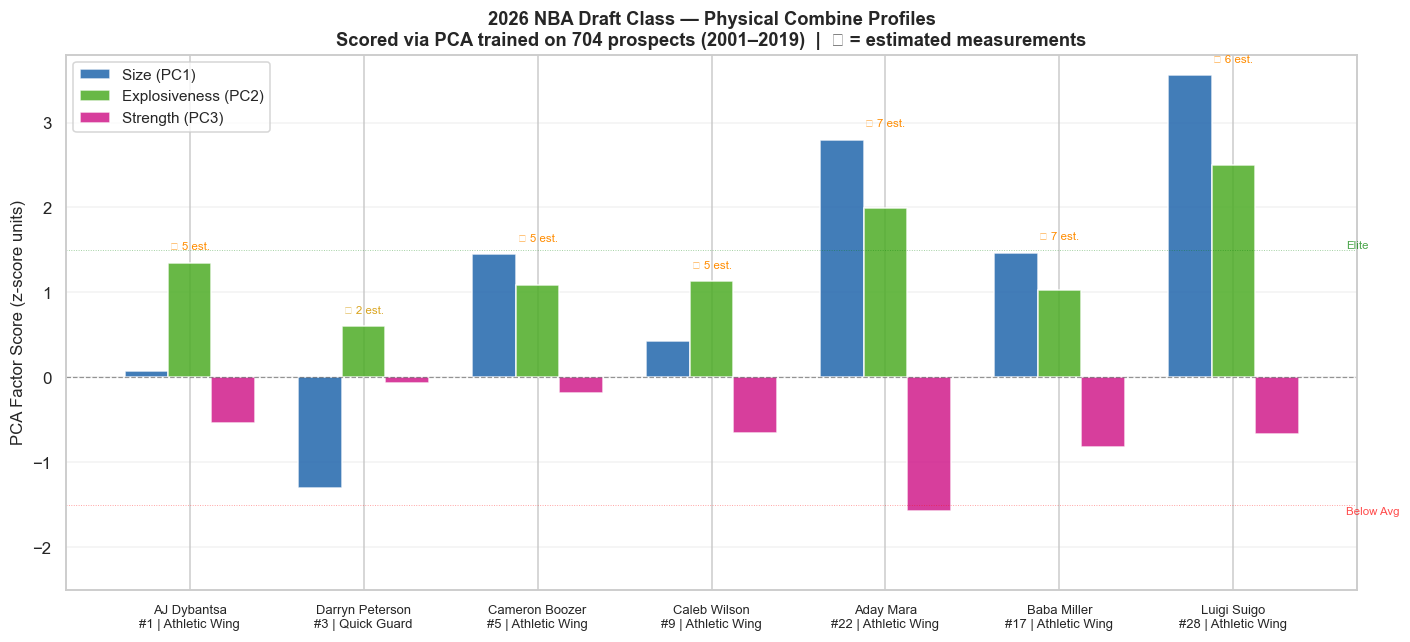

In [69]:
fig, ax = plt.subplots(figsize=(13, 6))

names_p  = [p['name'] for p in prospects_2026]
size_p   = [p['Size'] for p in prospects_2026]
expl_p   = [p['Explosiveness'] for p in prospects_2026]
str_p    = [p['Strength'] for p in prospects_2026]
imputed  = [p['imputed'] for p in prospects_2026]

x = np.arange(len(names_p))
w = 0.25

bars1 = ax.bar(x - w, size_p,  w, label='Size (PC1)',          color='#2166ac', alpha=0.85)
bars2 = ax.bar(x,     expl_p,  w, label='Explosiveness (PC2)', color='#4dac26', alpha=0.85)
bars3 = ax.bar(x + w, str_p,   w, label='Strength (PC3)',      color='#d01c8b', alpha=0.85)

# Imputation warning stars
for i, n_imp in enumerate(imputed):
    if n_imp >= 5:
        ax.text(i, max(size_p[i], expl_p[i], str_p[i]) + 0.15,
                f'⚠ {n_imp} est.', ha='center', fontsize=7.5, color='darkorange')
    elif n_imp > 0:
        ax.text(i, max(size_p[i], expl_p[i], str_p[i]) + 0.15,
                f'⚠ {n_imp} est.', ha='center', fontsize=7.5, color='goldenrod')

ax.axhline(0,    color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.axhline( 1.5, color='green', linewidth=0.6, linestyle=':',  alpha=0.4)
ax.axhline(-1.5, color='red',   linewidth=0.6, linestyle=':',  alpha=0.4)
ax.text(6.65,  1.52, 'Elite',       fontsize=7.5, color='green', alpha=0.7)
ax.text(6.65, -1.62, 'Below Avg',   fontsize=7.5, color='red',   alpha=0.7)

# Archetype + pick labels on x-axis
xlabels = [f"{p['name']}\n#{p['pick']} | {p['archetype']}" for p in prospects_2026]
ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=8.5)

ax.set_ylabel('PCA Factor Score (z-score units)', fontsize=11)
ax.set_title('2026 NBA Draft Class — Physical Combine Profiles\n'
             'Scored via PCA trained on 704 prospects (2001–2019)  |  ⚠ = estimated measurements',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(-2.5, 3.8)
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig('prospects_2026.png', dpi=150, bbox_inches='tight')
plt.show()

In [70]:
class_df = pd.DataFrame(prospects_2026)
class_df = class_df.sort_values('pick')
class_df['dark_horse_flag'] = class_df['archetype'] == 'Quick Guard'
print(class_df[['name','pick','archetype','Size','Explosiveness',
                'Strength','predicted_career','imputed']].to_string(index=False))

class_df.to_csv(Path('data') / 'prospects_2026_scores.csv', index=False)
print("\nSaved: prospects_2026_scores.csv")

           name  pick     archetype  Size  Explosiveness  Strength  predicted_career  imputed
    AJ Dybantsa     1 Athletic Wing  0.08           1.35     -0.54               9.3        5
Darryn Peterson     3   Quick Guard -1.30           0.60     -0.07               9.2        2
 Cameron Boozer     5 Athletic Wing  1.45           1.09     -0.18               8.7        5
   Caleb Wilson     9 Athletic Wing  0.43           1.13     -0.66               8.1        5
    Baba Miller    17 Athletic Wing  1.47           1.03     -0.82               6.9        7
      Aday Mara    22 Athletic Wing  2.80           1.99     -1.57               5.9        7
    Luigi Suigo    28 Athletic Wing  3.56           2.50     -0.67               5.2        6

Saved: prospects_2026_scores.csv
